# Evaluation Notebook

This notebook takes in the data from `evaluation_script.py`, and allows for generation of figures used in the paper



In [ ]:
PROJECT_ROOT = "."

In [ ]:
import os
import torch
import gc
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import json
from datasets import load_dataset
import re
import random
import argparse
import sys
sys.path.append(os.path.join(PROJECT_ROOT, "countdown"))
from countdown_task import reward_function
random.seed(42)

In [ ]:
import os, json, re, random, argparse, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Configuration

Adjust paths, tasks, and model checkpoints here before running the rest of the notebook.


In [ ]:
# --- Configuration ---

# keep directory for later 
CHECKPOINT_DIR = None # Enter your checkpoint directory here
# Helper to construct path
def get_model_path(iter_name):
    return os.path.join(CHECKPOINT_DIR, f"Qwen2.5-1.5B-Instruct_es_random_seed33_pop30_{iter_name}_sigma0.001_alpha0.0005_fp16_procs4_question_num200_checkpoint")

ES_MODELS_TO_EVALUATE = {
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "iter50": get_model_path("iter50"),
    "iter100": get_model_path("iter100"),
    "iter150": get_model_path("iter150"),
    "iter200": get_model_path("iter200"),
    "iter250": get_model_path("iter250"),
    "iter300": get_model_path("iter300"),
    "iter350": get_model_path("iter350"),
    "iter400": get_model_path("iter400"),
    "iter450": get_model_path("iter450"),
    "iter500": get_model_path("iter500"),
    "iter500_final": os.path.join(CHECKPOINT_DIR, "Qwen2.5-1.5B-Instruct_es_random_seed33_pop30_iter500_sigma0.001_alpha0.0005_fp16_procs4_question_num200_final")
}

DATASET_PATHS = {
    "countdown": os.path.join(PROJECT_ROOT, "countdown/data/test.parquet")
}
TASKS = ["countdown", "hellaswag"]
MODELS_TO_RUN = ["base_model", "iter100", "iter200", "iter300", "iter400", "iter500"]
CALC_FROBENIUS = True
CALC_KL = True
GPU_UTILIZATION = 0.8
CSV_OUTPUT_PATH = "results/es_evaluation_metrics.csv"

In [ ]:
# Read in csv
plot_df = pd.read_csv(CSV_OUTPUT_PATH)

Figure A1: Relationship between KL divergence and task performance

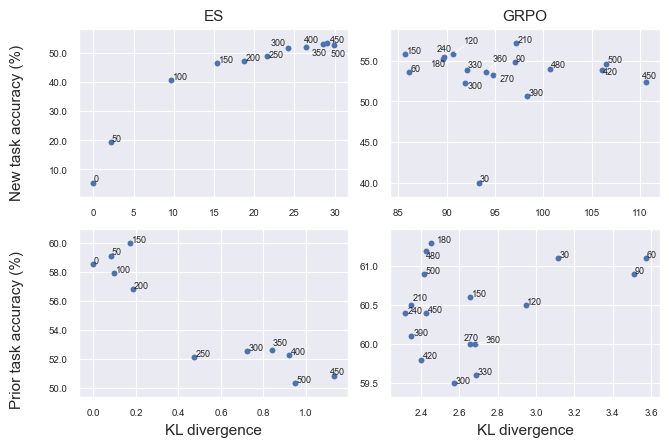

In [ ]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

def plot_kl_relationships_2x2_acl(df, out_base="results/kl_relationships_2x2"):
    df = df.copy()

    # Convert scores to percentages (assumes scores in [0, 1])
    for p in ["es", "grpo"]:
        cd = f"{p}-countdown-score"
        hs = f"{p}-hellaswag-score"
        if cd in df.columns:
            df[cd] = df[cd] * 100.0
        if hs in df.columns:
            df[hs] = df[hs] * 100.0

    sns.set_theme(style="darkgrid", context="paper", font_scale=0.8)

    fig, axes = plt.subplots(2, 2, figsize=(6.75, 4.6), sharex=False, sharey=False)

    def _panel(ax, prefix, x_suffix, y_suffix):
        xcol = f"{prefix}-{x_suffix}"
        ycol = f"{prefix}-{y_suffix}"

        plot_df = df.dropna(subset=[xcol, ycol]).copy()
        if plot_df.empty:
            ax.set_axis_off()
            return

        sns.scatterplot(
            data=plot_df,
            x=xcol,
            y=ycol,
            s=18,
            linewidth=0,
            ax=ax,
        )

        # Iteration labels (numbers only) + leader lines
        texts = []
        if "iteration" in plot_df.columns:
            for _, row in plot_df.iterrows():
                texts.append(
                    ax.text(
                        row[xcol],
                        row[ycol],
                        f"{int(row['iteration'])}",
                        fontsize=6.5,
                    )
                )
            adjust_text(
                texts,
                ax=ax,
                expand_points=(1.6, 1.6),
                expand_text=(1.3, 1.3),
                force_points=0.4,
                force_text=0.5,
                arrowprops=dict(arrowstyle="-", linewidth=0.6),
            )

        # Percent tick labels (consistent precision)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax.tick_params(labelsize=7)
        ax.margins(x=0.06, y=0.10)

    # Top row: Countdown vs KL
    _panel(axes[0, 0], "es",   "countdown-kl", "countdown-score")
    _panel(axes[0, 1], "grpo", "countdown-kl", "countdown-score")

    # Bottom row: HellaSwag vs KL
    _panel(axes[1, 0], "es",   "hellaswag-kl", "hellaswag-score")
    _panel(axes[1, 1], "grpo", "hellaswag-kl", "hellaswag-score")

    # Remove per-axis y-labels; we’ll add row-level labels instead
    for ax in axes.ravel():
        ax.set_ylabel("")

    # X label only on bottom row
    axes[0, 0].set_xlabel("")
    axes[0, 1].set_xlabel("")
    axes[1, 0].set_xlabel("KL divergence", fontsize=11)
    axes[1, 1].set_xlabel("KL divergence", fontsize=11)

    # Column headers only
    axes[0, 0].set_title("ES", fontsize=11, pad=6)
    axes[0, 1].set_title("GRPO", fontsize=11, pad=6)

    # Row-level y labels (figure-level)
    fig.text(0.02, 0.73, "New task accuracy (%)", rotation=90, va="center", fontsize=11)
    fig.text(0.02, 0.28, "Prior task accuracy (%)", rotation=90, va="center", fontsize=11)

    # Tight layout with a bit of left margin for the row labels
    fig.tight_layout(rect=[0.06, 0.02, 1.0, 1.0])

    fig.savefig(f"{out_base}.pdf", bbox_inches="tight")
    fig.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# Usage:
plot_kl_relationships_2x2_acl(plot_df)



Figure 1: Pareto front between new task and old task performance across fine tuning with ES and GRPO

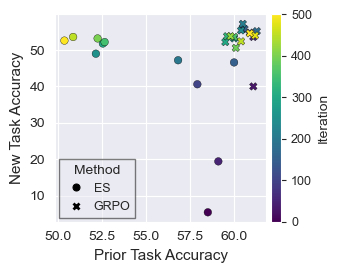

Saved results/countdown_vs_hellaswag_colored_by_iteration.png


In [ ]:
from matplotlib.lines import Line2D
def plot_new_vs_old_colored_by_iteration(
    df,
    old_task="hellaswag",
    new_task="countdown",
    prefixes=("es", "grpo"),
    savepath="results/countdown_vs_hellaswag_colored_by_iteration.png",
):
    rows = []
    for pref in prefixes:
        xcol = f"{pref}-{old_task}-score"
        ycol = f"{pref}-{new_task}-score"

        if xcol not in df.columns or ycol not in df.columns:
            continue

        tmp = df[["iteration", xcol, ycol]].copy()
        tmp = tmp.rename(columns={xcol: "old_score", ycol: "new_score"})
        tmp["method"] = pref.upper()
        tmp = tmp.dropna(subset=["old_score", "new_score"])
        # Multiply accuracies by 100 for percentage
        tmp["old_score"] = tmp["old_score"] * 100.0
        tmp["new_score"] = tmp["new_score"] * 100.0
        rows.append(tmp)

    if not rows:
        raise ValueError("No valid data found to plot.")

    plot_df = pd.concat(rows, ignore_index=True)

    fig, ax = plt.subplots(figsize=(3.25, 2.6))

    sns.scatterplot(
        data=plot_df,
        x="old_score",
        y="new_score",
        hue="iteration",
        style="method",
        palette="viridis",
        s=30,
        edgecolor="black",
        linewidth=0.25,
        legend=False,   # keep seaborn legend off
        ax=ax,
    )
    norm = plt.Normalize(plot_df["iteration"].min(), plot_df["iteration"].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(
        sm,
        ax=ax,
        fraction=0.05,
        pad=0.02,
    )
    cbar.set_label("Iteration", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xlabel("Prior Task Accuracy", fontsize=11)
    ax.set_ylabel("New Task Accuracy", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)


    legend_elements = [
	    Line2D(
	        [0], [0],
	        marker="o",
	        color="black",
	        label="ES",
	        linestyle="None",
	        markersize=5,
	        markeredgewidth=0.8,
	    ),
	    Line2D(
	        [0], [0],
	        marker="x",
	        color="black",
	        label="GRPO",
	        linestyle="None",
	        markersize=4,
	       	markeredgewidth=2.0,
	    ),
	]
    ax.legend(
	    handles=legend_elements,
	    title="Method",
	    title_fontsize=10,
	    fontsize=9,
	    loc="lower left",
	    frameon=True,
	    fancybox=False,
	    framealpha=0.5,
	    edgecolor="black",
	    handletextpad=0.4,
	    borderaxespad=0.3,
	)

    plt.tight_layout(pad=0.25)
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved {savepath}")
    
plot_new_vs_old_colored_by_iteration(
	plot_df)



Figure 2: Prior task accuruacy vs training iteration for ES and GRPO fine-tuning

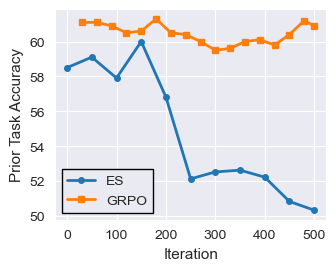

Saved results/hellaswag_vs_iteration.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

def plot_hellaswag_vs_iteration(df):
    df = df.copy()
    plt.figure(figsize=(3.25, 2.6))

    # ES
    df[["es-hellaswag-score"]] = df[["es-hellaswag-score"]] * 100
    es_df = df[["iteration", "es-hellaswag-score"]].dropna()
    plt.plot(
        es_df["iteration"],
        es_df["es-hellaswag-score"],
        marker="o",
        linewidth=2,
        markersize=4,
        label="ES",
    )

    # GRPO
    df[["grpo-hellaswag-score"]] = df[["grpo-hellaswag-score"]] * 100
    grpo_df = df[["iteration", "grpo-hellaswag-score"]].dropna()
    plt.plot(
        grpo_df["iteration"],
        grpo_df["grpo-hellaswag-score"],
        marker="s",
        linewidth=2,
        markersize=4,
        label="GRPO",
    )

    plt.xlabel("Iteration", fontsize=11)
    plt.ylabel("Prior Task Accuracy", fontsize=11)

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.legend(
        fontsize=10,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor="black",
    )

    plt.tight_layout(pad=0.3)

    plt.savefig(
        "results/hellaswag_vs_iteration.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()
    print("Saved results/hellaswag_vs_iteration.png")
plot_hellaswag_vs_iteration(plot_df)

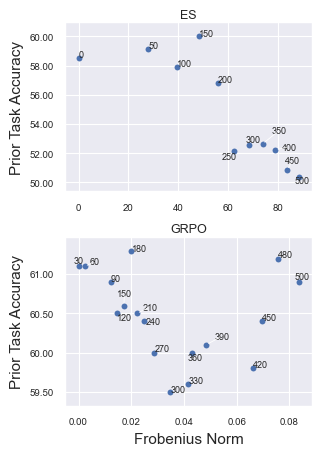

In [ ]:
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text

def plot_hellaswag_score_vs_frobenius_stacked(df):
    df = df.copy()
    if "es-hellaswag-score" in df.columns:
        df["es-hellaswag-score"] *= 100.0
    if "grpo-hellaswag-score" in df.columns:
        df["grpo-hellaswag-score"] *= 100.0

    sns.set_theme(style="darkgrid", context="paper", font_scale=0.8)

    # IMPORTANT: sharex=False so each panel has its own x-scale
    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        figsize=(3.25, 4.6),
        sharex=False,
    )

    def _panel(ax, metric_prefix, panel_title, show_xlabel):
        frob_col = f"{metric_prefix}-frobenius-norm"
        score_col = f"{metric_prefix}-hellaswag-score"

        plot_df = df.dropna(subset=[frob_col, score_col])
        if plot_df.empty:
            ax.set_axis_off()
            return

        sns.scatterplot(
            data=plot_df,
            x=frob_col,
            y=score_col,
            s=18,
            linewidth=0,
            ax=ax,
        )

        texts = []
        if "iteration" in plot_df.columns:
            for _, row in plot_df.iterrows():
                texts.append(
                    ax.text(
                        row[frob_col],
                        row[score_col],
                        f"{int(row['iteration'])}",
                        fontsize=6.5,
                    )
                )
            adjust_text(
                texts,
                ax=ax,
                expand_points=(1.6, 1.6),
                expand_text=(1.3, 1.3),
                force_points=0.4,
                force_text=0.5,
                arrowprops=dict(arrowstyle="-", linewidth=0.6),
            )

        ax.set_title(panel_title, fontsize=9, pad=3)
        ax.set_ylabel("Prior Task Accuracy", fontsize=11)
        ax.tick_params(labelsize=7)

        # Same numeric precision on Y axis for both panels
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        if show_xlabel:
            ax.set_xlabel("Frobenius Norm", fontsize=11)
        else:
            ax.set_xlabel("")

        # Small padding so labels/points don’t sit on the frame
        ax.margins(x=0.06, y=0.10)

    _panel(axes[0], "es",   "ES",   show_xlabel=False)
    _panel(axes[1], "grpo", "GRPO", show_xlabel=True)

    fig.tight_layout()
    fig.savefig("results/hellaswag_score_vs_frobenius_stacked.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
plot_hellaswag_score_vs_frobenius_stacked(plot_df)

Figure 3: Relationship between Frobenius norm of a model update and number of training iterations on a new task.  Set log_scale to False to obtain Figure A2.

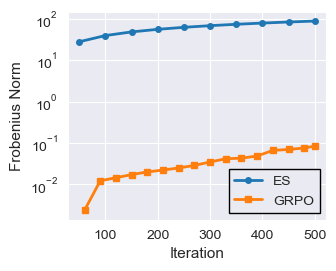

Saved results/frobenius_vs_iteration.png


In [ ]:
def plot_frobenius_vs_iteration(df, log_scale = False):
    df = df.copy()
    plt.figure(figsize=(3.25, 2.6))

    # --- ES ---
    es_df = df[["iteration", "es-frobenius-norm"]].dropna()
    es_df = pd.concat(
        [
            pd.DataFrame({"iteration": [0], "es-frobenius-norm": [0.0]}),
            es_df,
        ],
        ignore_index=True,
    ).sort_values("iteration")
    if log_scale:
        plt.yscale("log")
        # remove iteration 0 from x-axis
        es_df = es_df[es_df["iteration"] >= 50]
    plt.plot(
        es_df["iteration"],
        es_df["es-frobenius-norm"],
        marker="o",
        linewidth=2,
        markersize=4,
        label="ES",
    )

    # --- GRPO ---
    grpo_df = df[["iteration", "grpo-frobenius-norm"]].dropna()
    grpo_df = pd.concat(
        [
            pd.DataFrame({"iteration": [0], "grpo-frobenius-norm": [0.0]}),
            grpo_df,
        ],
        ignore_index=True,
    ).sort_values("iteration")
    if log_scale:
        grpo_df = grpo_df[grpo_df["iteration"] >= 50]
    plt.plot(
        grpo_df["iteration"],
        grpo_df["grpo-frobenius-norm"],
        marker="s",
        linewidth=2,
        markersize=4,
        label="GRPO",
    )

    plt.xlabel("Iteration", fontsize=11)
    plt.ylabel("Frobenius Norm", fontsize=11)
    

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    plt.legend(
        fontsize=10,
        frameon=True,
        fancybox=False,
        framealpha=1.0,
        edgecolor="black",
    )

    plt.tight_layout(pad=0.3)

    plt.savefig(
        "results/frobenius_vs_iteration.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    print("Saved results/frobenius_vs_iteration.png")
plot_frobenius_vs_iteration(plot_df, log_scale = False)